# 10 — The pntoy Diode: Band Diagrams Under Bias

The [pntoy tool on nanoHUB](https://nanohub.org/tools/pntoy) is many students' first device simulation. It runs PADRE on a
silicon p-n junction and shows band diagrams, carrier densities and the I-V curve. This notebook rebuilds the pntoy diode
with `nanohubpadre` and asks one question: **when does the band diagram look like the one in the textbook, and when does
it stop looking like it?**

You will see that:
* at **low forward bias** (≲ 0.4 V for pntoy's defaults) the simulated band diagram *is* the textbook picture: flat bands
  in the neutral regions, flat quasi-Fermi levels split by exactly $qV$ across the depletion region, and a barrier lowered by $qV$;
* at **high bias** it distorts: the quasi-Fermi levels tilt, the bands slope through the "neutral" regions, and above
  $V_{bi}$ the textbook picture cannot even be drawn;
* the distortion has three ingredients: **ohmic drop in the neutral regions** (the dominant one here), the **approach to
  high injection**, and a soft **$V_{bi}$ wall** that makes the junction voltage stall.

Section 10 then previews three fixes (more doping, better silicon, shorter neutral regions), each shown **side by
side with the pntoy default at 0.8 V**, so you can see what a repaired band diagram looks like.
[Notebook 11](11_Keeping_the_Textbook_Picture.ipynb) explores every design knob in depth (doping, length, lifetime,
area, temperature) and measures which changes keep the textbook picture valid to higher bias.

**Prerequisites:** [02 — PN Junction Diode](02_PN_Diode.ipynb).

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
# PADRE is a compiled simulator. On nanoHUB it lives in an environment
# module that must be loaded into this Python kernel before the first
# simulation runs; elsewhere, PADRE just needs to be on your PATH.
import shutil
from nanohubpadre import use

if shutil.which("padre") is None:
    try:
        use("padre-2.4E-r15")          # nanoHUB module name
    except Exception as exc:           # not on nanoHUB: that is fine
        print("Could not load the PADRE module:", exc)

print("PADRE executable:", shutil.which("padre") or "NOT FOUND - simulations will fail")

PADRE executable: /apps/share64/debian10/padre/padre-2.4E/r15/bin/padre


In [2]:
# ── Physical constants: textbook values vs. the values PADRE really uses ──
# PADRE prints its constants with `MODELS ... PRINT`. A fair comparison of
# simulation against a formula must feed the formula PADRE's numbers:
# e.g. the textbook n_i = 1.5e10 cm^-3 alone changes every analytic diode
# current by (1.5e10 / 9.963e9)^2 = 2.3x before any physics is compared.
import numpy as np

Q      = 1.602e-19        # elementary charge (C)
KT     = 0.025851         # thermal voltage kT/q at 300 K (V)
EPS0   = 8.854e-14        # vacuum permittivity (F/cm)
EPS_SI = 11.8 * EPS0      # silicon permittivity in PADRE (F/cm)
EPS_OX = 3.9 * EPS0       # SiO2 permittivity (F/cm)
NI     = 9.963e9          # intrinsic carrier density of Si at 300 K (cm^-3)
EG     = 1.12             # band gap (eV)
CHI_SI = 4.17             # electron affinity of Si in PADRE (eV)
NC, NV = 3.2e19, 2.03e19  # effective densities of states (cm^-3)

# The values most textbooks quote (e.g. Sze & Ng, Pierret), for contrast.
TEXTBOOK = dict(NI=1.5e10, EPS_SI=11.7 * EPS0, CHI_SI=4.05, NC=2.8e19, NV=1.04e19)


def compare(rows, title="Textbook vs. PADRE"):
    """Print a comparison table.

    rows: list of (quantity, textbook_value, padre_value, unit, why_different)
    """
    print(title)
    print("-" * 125)
    print(f"{'quantity':<40}{'textbook':>12}{'PADRE':>12}{'diff':>9}   why they differ")
    print("-" * 125)
    for name, tb, pd, unit, why in rows:
        d = f"{(pd - tb) / tb * 100:>+8.1f}%" if tb else "     n/a "
        print(f"{name + ' (' + unit + ')':<40}{tb:>12.4g}{pd:>12.4g}{d}   {why}")
    print("-" * 125)


compare([
    ("intrinsic density n_i", TEXTBOOK["NI"], NI, "cm^-3",
     "modern value (Sproul & Green 1991); 1.5e10 is the older textbook number"),
    ("Si permittivity", TEXTBOOK["EPS_SI"], EPS_SI, "F/cm", "PADRE uses eps_r = 11.8, Sze uses 11.7"),
    ("electron affinity chi", TEXTBOOK["CHI_SI"], CHI_SI, "eV", "PADRE (like Silvaco Atlas) uses 4.17"),
    ("conduction-band DOS Nc", TEXTBOOK["NC"], NC, "cm^-3", "different effective-mass fit"),
    ("valence-band DOS Nv", TEXTBOOK["NV"], NV, "cm^-3", "different effective-mass fit"),
], title="Material constants")

Material constants
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
intrinsic density n_i (cm^-3)                1.5e+10   9.963e+09   -33.6%   modern value (Sproul & Green 1991); 1.5e10 is the older textbook number
Si permittivity (F/cm)                     1.036e-12   1.045e-12    +0.9%   PADRE uses eps_r = 11.8, Sze uses 11.7
electron affinity chi (eV)                      4.05        4.17    +3.0%   PADRE (like Silvaco Atlas) uses 4.17
conduction-band DOS Nc (cm^-3)               2.8e+19     3.2e+19   +14.3%   different effective-mass fit
valence-band DOS Nv (cm^-3)                 1.04e+19    2.03e+19   +95.2%   different effective-mass fit
---------------------------------------------------

---
## 1. The pntoy structure

| Parameter | pntoy default | Used here |
|---|---|---|
| material | Si | Si (PADRE's built-in parameters) |
| p region | 3 µm, $N_A$ = 2×10¹⁵ cm⁻³ | same |
| n region | 6 µm, $N_D$ = 1×10¹⁵ cm⁻³ | same |
| lifetimes $\tau_n=\tau_p$ | 10⁻¹⁰ s | same |
| temperature | 300 K | same |
| models | `srh conmob fldmob impact` | `srh conmob fldmob` (impact ionization is irrelevant in forward bias) |
| forward sweep | 0 → 0.6 V, 20 points | 0 → 1.0 V in 0.05 V steps |

Two notes for anyone comparing numbers with the tool itself:
* pntoy tries to pass its own silicon parameters (Pierret's $E_g$, $N_C$, $N_V$), but it writes them on a continuation
  line after a comment, and PADRE discards them ("comment line continued" in the PADRE log). pntoy therefore runs on
  PADRE's built-in silicon, the same as this notebook: $n_i$ = 9.963×10⁹ cm⁻³.
* The lifetime default, 0.1 ns, is about 10⁴ times shorter than in good silicon. It makes recombination in the depletion
  region dominate the current at low bias (ideality factor ≈ 1.8, see notebook 02). Here it matters mostly because it sets
  how much current flows at a given voltage.

The lightly doped n side ($N_D$ = 10¹⁵ cm⁻³) holds two thirds of the depletion region. It is also twice as long as the
p side, so despite the higher electron mobility it carries slightly more of the series resistance.

In [3]:
# ── The pntoy diode, rebuilt with nanohubpadre ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from nanohubpadre import create_pn_diode, Solve


def tag(v):
    """File-name tag for a bias point: 0.35 V -> 'v0350'."""
    return f"v{int(round(v * 1000)):04d}"


def pntoy_diode(p_len=3.0, n_len=6.0, Na=2e15, Nd=1e15, tau=1e-10, vmax=1.0, dv=0.05,
                temperature=300, depth=1.0, nx=400):
    """Silicon p-n diode with the pntoy tool's defaults, and a snapshot of the
    band diagram (Ec, Ev, Efn, Efp) plus carrier profiles at every bias step.

    p_len, n_len : lengths of the p and n regions (um); contacts at both ends
    Na, Nd       : uniform doping (cm^-3);  tau : SRH lifetimes (s)
    vmax, dv     : forward sweep 0 -> vmax on the p contact, in steps of dv (V)
    depth        : device depth into the page (um); currents scale with it
    """
    L = p_len + n_len
    sim = create_pn_diode(length=L, junction_position=p_len / L, p_doping=Na, n_doping=Nd,
                          taun0=tau, taup0=tau, nx=nx, temperature=temperature,
                          device_z_width=depth, log_iv=True)
    biases = np.round(np.arange(0.0, vmax + 1e-9, dv), 6)
    cut = dict(x_start=0.0, y_start=0.5, x_end=L, y_end=0.5)    # line through the middle
    sim.add_solve(Solve(initial=True))                            # equilibrium
    for k, v in enumerate(biases):
        if k > 0:   # one small step at a time, starting from the previous solution
            sim.add_solve(Solve(previous=True, v1=float(v), electrode=1))
        sim.log_band_diagram(tag(v), include_qf=True, **cut)      # Ec, Ev, Efn, Efp
        sim.log_physics(tag(v), **cut)                            # n, p, E-field, recombination
    sim.meta = dict(p_len=p_len, n_len=n_len, Na=Na, Nd=Nd, tau=tau, L=L, xj=p_len,
                    biases=biases, T=temperature, depth=depth)
    return sim


def snapshot(sim, v):
    """All profiles at bias v, as arrays along x (um). Energies in eV, densities in cm^-3."""
    t, g = tag(v), sim.outputs.get
    ec = g("cb" + t)
    return dict(x=ec.x, ec=ec.y, ev=g("vb" + t).y, fn=g("qfn" + t).y, fp=g("qfp" + t).y,
                n=np.abs(g("n_" + t).y), p=np.abs(g("p_" + t).y), ef=g("efield_" + t).y)


def voltage_budget(sim):
    """Split every applied bias V into  V = V_junction + V_p-side + V_n-side.

    V_junction : Efn - Efp at the metallurgical junction (textbook: all of V)
    V_p-side   : drop of the hole quasi-Fermi level from the p contact to the junction
    V_n-side   : drop of the electron quasi-Fermi level from the n contact to the junction
    """
    xj, rows = sim.meta["xj"], []
    for v in sim.meta["biases"]:
        s = snapshot(sim, v)
        fn_j, fp_j = np.interp(xj, s["x"], s["fn"]), np.interp(xj, s["x"], s["fp"])
        rows.append((v, fn_j - fp_j, fp_j - s["fp"][0], s["fn"][-1] - fn_j))
    return np.array(rows).T      # V, Vj, Vp, Vn


def fidelity_limit(V, Vj, level=0.9):
    """Highest bias at which the junction still receives `level` of the applied voltage."""
    f = np.where(V > 0, Vj / np.maximum(V, 1e-12), 1.0)
    k = np.where(f < level)[0]
    if len(k) == 0:
        return np.inf
    k = k[0]
    return V[k - 1] + (f[k - 1] - level) / (f[k - 1] - f[k]) * (V[k] - V[k - 1])

In [4]:
Na, Nd, P_LEN, N_LEN, XJ = 2e15, 1e15, 3.0, 6.0, 3.0

sim = pntoy_diode()                  # pntoy defaults, swept to 1.0 V
res = sim.run()
assert res.returncode == 0, res.stdout[-2000:]
V, Vj, Vp, Vn = voltage_budget(sim)
iv = sim.get_iv_data()
I = iv.get_currents(1)                                   # A per um of depth
J = I * 1e8 / sim.meta["depth"]                          # A/cm^2 (1 um x 1 um cross-section per um of depth)
print(f"{len(V)} bias points solved, 0 to {V[-1]:.2f} V")

Using cached results from '/tmp/nbrun_padre/pn_junction_diode_db5e0ca3a165d32947a5d792e88209a3'
21 bias points solved, 0 to 1.00 V


---
## 2. The textbook picture under forward bias

The textbook (Sze & Ng §2.3, Pierret ch. 6) describes a forward-biased junction with four statements:

1. **All of the applied voltage appears across the depletion region.** The barrier drops from $qV_{bi}$ to $q(V_{bi}-V)$,
   and the depletion width shrinks as
   $W(V)=\sqrt{\frac{2\varepsilon_s}{q}\big(\frac1{N_A}+\frac1{N_D}\big)(V_{bi}-V)}$.
2. **The quasi-Fermi levels are flat through the depletion region** and split by exactly $qV$:
   $E_{Fn}-E_{Fp}=qV$, so $np=n_i^2e^{qV/kT}$ there.
3. **The neutral regions carry no field.** The bands are flat there, and each majority quasi-Fermi level stays pinned at its contact.
4. **Low injection.** The injected minority density at the depletion edge,
   $p_n(x_n)=\frac{n_i^2}{N_D}e^{qV/kT}$ (the *law of the junction*), stays far below the majority density $N_D$.

Statements 1 and 4 carry their own limits, which you can compute before simulating anything:

* statement 1 requires $V<V_{bi}$, otherwise $W$ is imaginary;
* statement 4 requires $p_n(x_n)\ll N_D$, i.e. $V\ll V_{HI}$ with
  $$V_{HI}=\frac{2kT}{q}\ln\frac{N}{n_i}$$
  for each side. This is the bias at which the injected minority density reaches the doping.

In [5]:
vbi = KT * np.log(Na * Nd / NI ** 2)
v_hi_n = 2 * KT * np.log(Nd / NI)          # holes injected into the n side reach N_D
v_hi_p = 2 * KT * np.log(Na / NI)          # electrons injected into the p side reach N_A
w0 = np.sqrt(2 * EPS_SI / Q * (1 / Na + 1 / Nd) * vbi) * 1e4

print(f"built-in potential            V_bi   = {vbi:.3f} V")
print(f"high injection, n side (1e15) V_HI,n = {v_hi_n:.3f} V")
print(f"high injection, p side (2e15) V_HI,p = {v_hi_p:.3f} V")
print(f"equilibrium depletion width   W(0)   = {w0:.2f} um  (of a 9 um device)")

built-in potential            V_bi   = 0.613 V
high injection, n side (1e15) V_HI,n = 0.595 V
high injection, p side (2e15) V_HI,p = 0.631 V
equilibrium depletion width   W(0)   = 1.10 um  (of a 9 um device)


pntoy's default sweep stops at 0.6 V, which is almost exactly where both limits sit. The last points of a default pntoy
run are therefore already outside the textbook's validity. That is not a flaw of the tool; it is the most interesting
part of the plot.

---
## 3. Low bias: the textbook band diagram, reproduced

We draw the textbook band diagram at 0.2 V on top of PADRE's. The textbook curve uses the depletion approximation, with
parabolic bands inside $-x_p<x-x_j<x_n$ and flat bands outside. It is anchored to PADRE's conduction band at the n contact.
Quasi-Fermi levels are drawn flat through the depletion region: $E_{Fn}$ = 0 (the n contact) and $E_{Fp}=-qV$ (the p contact).

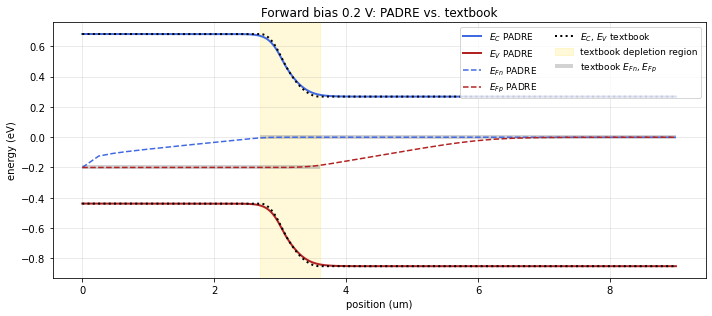

largest |Ec(PADRE) - Ec(textbook)| anywhere: 17.7 meV
quasi-Fermi splitting at the junction: 0.1996 eV for qV = 0.2000 eV


In [6]:
def textbook_bands(x, v, ec_n, Na=Na, Nd=Nd, xj=XJ):
    # depletion-approximation Ec(x) in eV; None if V >= Vbi (no textbook solution)
    vb = KT * np.log(Na * Nd / NI ** 2)
    if v >= vb:
        return None
    W = np.sqrt(2 * EPS_SI / Q * (1 / Na + 1 / Nd) * (vb - v))          # cm
    xp, xn = W * Nd / (Na + Nd), W * Na / (Na + Nd)
    d = (x - xj) * 1e-4                                                  # cm from the junction
    ec = np.full_like(x, ec_n)
    ec[d <= -xp] = ec_n + (vb - v)
    m = (d > -xp) & (d <= 0)
    ec[m] = ec_n + (vb - v) - Q * Na * (d[m] + xp) ** 2 / (2 * EPS_SI)
    m = (d > 0) & (d < xn)
    ec[m] = ec_n + Q * Nd * (xn - d[m]) ** 2 / (2 * EPS_SI)
    return ec, (xj - xp * 1e4, xj + xn * 1e4)

s = snapshot(sim, 0.2)
EG_SIM = s["ec"][0] - s["ev"][0]                     # PADRE's band gap
ec_tb, (xp_edge, xn_edge) = textbook_bands(s["x"], 0.2, s["ec"][-1])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(s["x"], s["ec"], color="royalblue", lw=2, label="$E_C$ PADRE")
ax.plot(s["x"], s["ev"], color="firebrick", lw=2, label="$E_V$ PADRE")
ax.plot(s["x"], s["fn"], color="royalblue", ls="--", label="$E_{Fn}$ PADRE")
ax.plot(s["x"], s["fp"], color="firebrick", ls="--", label="$E_{Fp}$ PADRE")
ax.plot(s["x"], ec_tb, color="black", ls=":", lw=2, label="$E_C$, $E_V$ textbook")
ax.plot(s["x"], ec_tb - EG_SIM, color="black", ls=":", lw=2)
ax.hlines(0.0, xp_edge, s["x"][-1], color="gray", lw=4, alpha=0.35, label="textbook $E_{Fn}$, $E_{Fp}$")
ax.hlines(-0.2, 0, xn_edge, color="gray", lw=4, alpha=0.35)
ax.axvspan(xp_edge, xn_edge, color="gold", alpha=0.15, label="textbook depletion region")
ax.set(xlabel="position (um)", ylabel="energy (eV)", title="Forward bias 0.2 V: PADRE vs. textbook")
ax.legend(ncol=2, fontsize=9, loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

err = np.max(np.abs(s["ec"] - ec_tb))
k = np.argmin(np.abs(s["x"] - XJ))
print(f"largest |Ec(PADRE) - Ec(textbook)| anywhere: {err * 1000:.1f} meV")
print(f"quasi-Fermi splitting at the junction: {Vj[V == 0.2][0]:.4f} eV for qV = 0.2000 eV")

**What agrees, and what is different**
* The bands in the neutral regions are flat, and the barrier has dropped by $qV$: $E_C$ on the p side sits exactly
  0.2 eV lower than at equilibrium, as statement 1 says.
* The quasi-Fermi levels are flat and split by $qV$ at the junction, to better than 1 mV (statement 2).
* The minority quasi-Fermi levels do not stay flat forever. $E_{Fn}$ on the p side (and $E_{Fp}$ on the n side)
  bends back to the majority level over a **diffusion length**, $L_n=\sqrt{D_n\tau_n}\approx$ 0.6 µm here. The textbook
  draws the same thing when it draws the diffusion tails; our grey bars stop at the depletion edges only to keep the plot readable.
* The only visible band-edge difference is at the **depletion edges**. The depletion approximation switches the charge on
  and off abruptly, while the real charge fades over a few Debye lengths ($L_D$ ≈ 0.1 µm at 10¹⁵ cm⁻³). This is the
  same $V_{bi}-2kT/q$ correction discussed in notebook 02.

---
## 4. Watching the band diagram distort

The same snapshot, from equilibrium to 1.0 V. Follow three features: the step between the two sides (the junction
barrier), the slope of the bands far from the junction, and the gap between $E_{Fn}$ and $E_{Fp}$ at the junction.

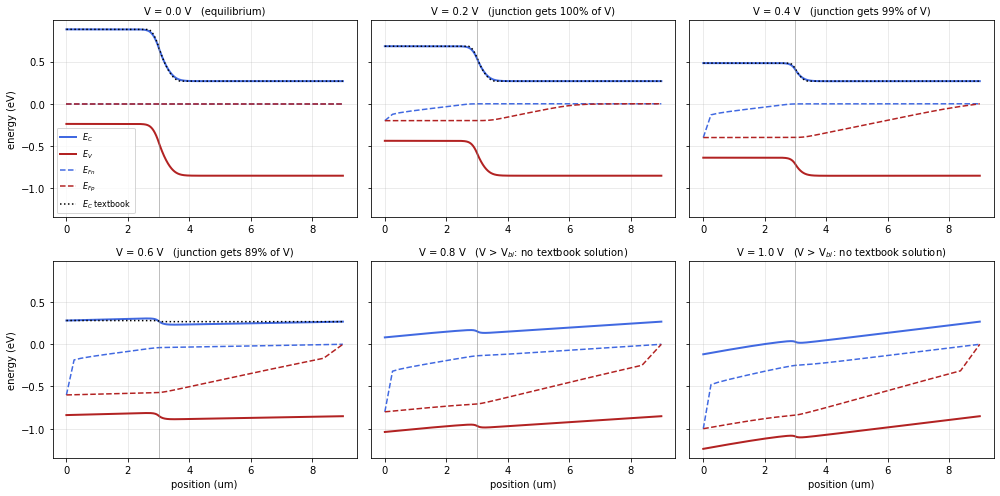

In [7]:
show = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, v in zip(axes.flat, show):
    s = snapshot(sim, v)
    ax.plot(s["x"], s["ec"], color="royalblue", lw=2, label="$E_C$")
    ax.plot(s["x"], s["ev"], color="firebrick", lw=2, label="$E_V$")
    ax.plot(s["x"], s["fn"], color="royalblue", ls="--", label="$E_{Fn}$")
    ax.plot(s["x"], s["fp"], color="firebrick", ls="--", label="$E_{Fp}$")
    tb = textbook_bands(s["x"], v, s["ec"][-1])
    if tb is not None:
        ax.plot(s["x"], tb[0], color="black", ls=":", lw=1.5, label="$E_C$ textbook")
        note = f"junction gets {Vj[np.isclose(V, v)][0] / v * 100:.0f}% of V" if v > 0 else "equilibrium"
    else:
        note = "V > V$_{bi}$: no textbook solution"
    ax.set_title(f"V = {v:.1f} V   ({note})", fontsize=10)
    ax.axvline(XJ, color="gray", lw=0.5); ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.set_xlabel("position (um)")
for ax in axes[:, 0]:
    ax.set_ylabel("energy (eV)")
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What you should see**
* **0 to 0.4 V:** textbook behaviour. The barrier shrinks by $qV$, the neutral bands stay flat, and PADRE's $E_C$ lies on
  the dotted textbook curve.
* **0.6 V:** the neutral regions begin to **tilt**. A tilted band means an electric field, and an electric field in a
  "neutral" region means a voltage drop that the junction does not receive. The quasi-Fermi splitting at the junction
  is now visibly smaller than $qV$.
* **0.8 and 1.0 V:** past $V_{bi}$. The textbook has no answer here, because $W$ would be imaginary. PADRE still converges:
  the junction keeps a small barrier, and every additional volt tilts the neutral regions further. At 1.0 V the
  conduction band at the p contact lies *below* the one at the n contact. A textbook drawing never shows this.

The rest of the notebook measures these effects one at a time.

---
## 5. Where does the applied voltage go?

The quasi-Fermi levels are the cleanest bookkeeping tool. Between the two contacts, the applied voltage splits exactly
into three parts:

$$qV=\underbrace{(E_{Fn}-E_{Fp})_{x_j}}_{qV_{junction}}+\underbrace{\Delta E_{Fp}\big|_{\text{p contact}\to x_j}}_{qV_{p\text{-side}}}
+\underbrace{\Delta E_{Fn}\big|_{x_j\to\text{n contact}}}_{qV_{n\text{-side}}}$$

The textbook says $V_{junction}=V$ and the other two are zero. The drops on the sides are carried by the **majority**
carriers (holes on the p side, electrons on the n side), so they are the ohmic, "resistor" part of the diode.

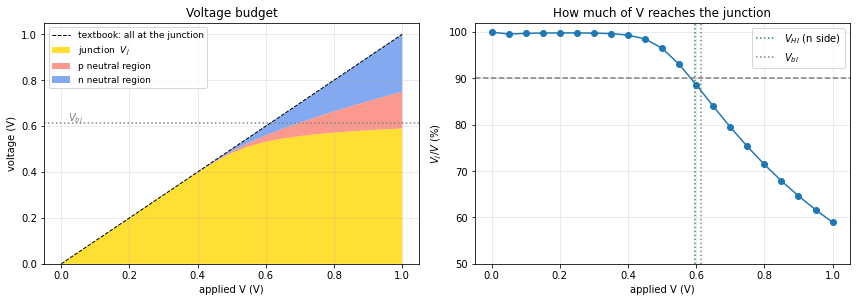

   V     V_junction   p side    n side    V_j/V
  0.20    0.200      0.000     0.000     99.8%
  0.40    0.397      0.001     0.002     99.4%
  0.50    0.483      0.007     0.010     96.5%
  0.60    0.532      0.028     0.040     88.6%
  0.70    0.557      0.059     0.084     79.5%
  0.80    0.571      0.093     0.136     71.4%
  1.00    0.590      0.161     0.250     59.0%

The junction receives >= 90% of V up to 0.58 V.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.stackplot(V, Vj, Vp, Vn, labels=["junction  $V_j$", "p neutral region", "n neutral region"],
              colors=["gold", "salmon", "cornflowerblue"], alpha=0.8)
ax1.plot(V, V, "k--", lw=1, label="textbook: all at the junction")
ax1.axhline(vbi, color="gray", ls=":"); ax1.text(0.02, vbi + 0.01, "$V_{bi}$", color="gray")
ax1.set(xlabel="applied V (V)", ylabel="voltage (V)", title="Voltage budget"); ax1.legend(fontsize=9, loc="upper left")
frac = np.where(V > 0, Vj / np.maximum(V, 1e-12), 1)
ax2.plot(V, frac * 100, "o-")
ax2.axhline(90, color="gray", ls="--"); ax2.axvline(v_hi_n, color="seagreen", ls=":", label="$V_{HI}$ (n side)")
ax2.axvline(vbi, color="gray", ls=":", label="$V_{bi}$")
ax2.set(xlabel="applied V (V)", ylabel="$V_j / V$ (%)", title="How much of V reaches the junction", ylim=(50, 102))
ax2.legend()
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("   V     V_junction   p side    n side    V_j/V")
for v in (0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0):
    k = np.argmin(abs(V - v))
    print(f"  {V[k]:.2f}    {Vj[k]:.3f}      {Vp[k]:.3f}     {Vn[k]:.3f}    {Vj[k] / V[k] * 100:5.1f}%")
print(f"\nThe junction receives >= 90% of V up to {fidelity_limit(V, Vj):.2f} V.")

**Reading the budget**
* Up to 0.4 V more than 99% of the voltage sits at the junction, and the textbook is right.
* Between 0.45 and 0.6 V the side drops grow quickly, and the n side (lighter doping, twice as long) takes the larger share.
* Above $V_{bi}$ the junction voltage almost stops growing: it creeps from 0.53 V at 0.6 V to 0.59 V at 1.0 V. **Nearly all
  of each extra volt ends up across the neutral regions.**

Two physical mechanisms produce this. Sections 6 and 7 isolate them.

---
## 6. Mechanism 1: high injection

The law of the junction predicts the minority density at the depletion edge. When that density approaches the doping,
the "minority" carriers are no longer a minority. The majority density must rise to keep the region neutral, and
the simple exponential law breaks down.

To measure this we need the edge of the neutral region at every bias. The definition that works at any injection level is
**where charge neutrality is restored**: on the n side, the first point where $n=N_D+p$ to within 10%.

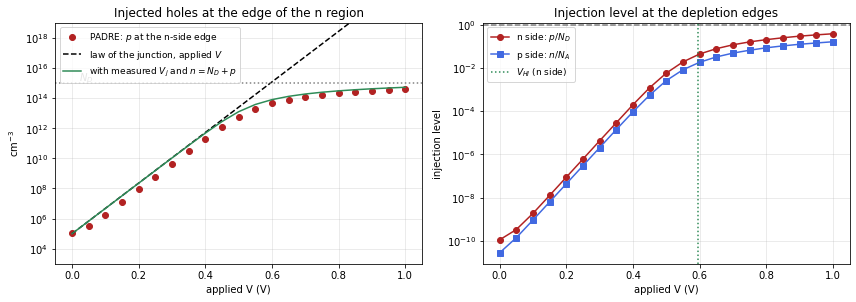

V = 0.4 V:  p/N_D = 0.000198   law of the junction overestimates p by     2.63x
V = 0.6 V:  p/N_D =   0.0444   law of the junction overestimates p by     26.9x
V = 0.8 V:  p/N_D =    0.205   law of the junction overestimates p by 1.33e+04x
V = 1.0 V:  p/N_D =    0.385   law of the junction overestimates p by 1.63e+07x


In [9]:
def neutral_edges(s, Na=Na, Nd=Nd, xj=XJ):
    x, n, p = s["x"], s["n"], s["p"]
    right = np.where((x > xj) & (np.abs(n - p - Nd) < 0.1 * Nd))[0][0]
    left = np.where((x < xj) & (np.abs(p - n - Na) < 0.1 * Na))[0][-1]
    return left, right

rows = []
for v in V:
    s = snapshot(sim, v)
    kl, kr = neutral_edges(s)
    rows.append((v, s["p"][kr], s["n"][kl], s["x"][kr] - s["x"][kl]))
Vv, p_edge, n_edge, W_sim = np.array(rows).T

vj_at = np.interp(Vv, V, Vj)
p_law = NI ** 2 / Nd * np.exp(Vv / KT)                                    # textbook, with the applied V
p_hi = (-Nd + np.sqrt(Nd ** 2 + 4 * NI ** 2 * np.exp(vj_at / KT))) / 2    # np = ni^2 exp(Vj/kT) with n = Nd + p

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.semilogy(Vv, p_edge, "o", color="firebrick", label="PADRE: $p$ at the n-side edge")
ax1.semilogy(Vv, p_law, "--", color="black", label="law of the junction, applied $V$")
ax1.semilogy(Vv, p_hi, "-", color="seagreen", label="with measured $V_j$ and $n=N_D+p$")
ax1.axhline(Nd, color="gray", ls=":"); ax1.text(0.02, Nd * 1.5, "$N_D$", color="gray")
ax1.set(xlabel="applied V (V)", ylabel="cm$^{-3}$", title="Injected holes at the edge of the n region", ylim=(1e3, 1e19))
ax1.legend(fontsize=9)
ax2.semilogy(Vv, p_edge / Nd, "o-", color="firebrick", label="n side: $p/N_D$")
ax2.semilogy(Vv, n_edge / Na, "s-", color="royalblue", label="p side: $n/N_A$")
ax2.axhline(1, color="gray", ls="--"); ax2.axvline(v_hi_n, color="seagreen", ls=":", label="$V_{HI}$ (n side)")
ax2.set(xlabel="applied V (V)", ylabel="injection level", title="Injection level at the depletion edges")
ax2.legend(fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for v in (0.4, 0.6, 0.8, 1.0):
    k = np.argmin(abs(Vv - v))
    print(f"V = {v:.1f} V:  p/N_D = {p_edge[k] / Nd:8.3g}   law of the junction overestimates p by {p_law[k] / p_edge[k]:8.3g}x")

**What is different, and why**
* At low bias PADRE's edge density rises one decade per 60 mV, parallel to the law of the junction (black dashes).
  The constant factor of about 2.6 between them comes from *where* we put the edge. With $L_p\approx$ 0.35 µm the hole
  density falls steeply just outside the depletion region, and the edge itself is smeared over a few Debye lengths.
  Change the 10% criterion in `neutral_edges` to 50% and the factor moves to about 0.8. Edge densities are only good to
  a factor of ~2, which is plenty for what follows.
* Above ~0.5 V the law of the junction with the applied $V$ overestimates the hole density by 27× at 0.6 V and by more than
  10⁴× at 0.8 V. It keeps growing as $e^{qV/kT}$, while the junction receives only $V_j$.
* The green curve applies the same law, $np=n_i^2e^{qV_j/kT}$, with the voltage the junction actually receives and with
  neutrality $n=N_D+p$. It stays within the same factor of ~2 of PADRE at every bias. **The law is not wrong; the textbook
  feeds it the wrong voltage.**
* The injection level rises to $p/N_D\approx$ 0.04 at 0.6 V and ≈ 0.4 at 1.0 V. The pntoy diode *approaches* high
  injection but never fully enters it. The ohmic drop of Section 7 keeps the junction voltage from climbing much past
  $V_{HI}$ = 0.60 V, so the resistors, not high injection, are what distort this diode's band diagram.

---
## 7. Mechanism 2: ohmic drop in the neutral regions

A neutral region is a resistor. With PADRE's mobility model (Masetti, validated in notebook 09), the two neutral regions
of the pntoy diode have a series resistance of

$$R_s A=\frac{W_p'}{qN_A\mu_p(N_A)}+\frac{W_n'}{qN_D\mu_n(N_D)},$$

where $W'$ are the neutral widths. Multiplying by the current density predicts the side drops of Section 5, provided
the carrier densities stay equal to the doping (low injection).

In [10]:
def masetti(N, typ):
    # Masetti, Severi & Solmi 1983: the conmob model PADRE implements
    if typ == "n":
        mu0, mumax, mu1, Cr, Cs, a, b, Pc = 52.2, 1417, 43.4, 9.68e16, 3.43e20, 0.680, 2.0, 0.0
    else:
        mu0, mumax, mu1, Cr, Cs, a, b, Pc = 44.9, 470.5, 29.0, 2.23e17, 6.10e20, 0.719, 2.0, 9.23e16
    return mu0 * np.exp(-Pc / N) + (mumax - mu0) / (1 + (N / Cr) ** a) - mu1 / (1 + (Cs / N) ** b)

rho_p, rho_n = 1 / (Q * Na * masetti(Na, "p")), 1 / (Q * Nd * masetti(Nd, "n"))
print(f"resistivity: p side {rho_p:.2f} Ohm cm,  n side {rho_n:.2f} Ohm cm")

kl_kr = [neutral_edges(snapshot(sim, v)) for v in V]
x_all = snapshot(sim, 0.0)["x"]
Wp = np.array([x_all[kl] for kl, kr in kl_kr]) * 1e-4                    # cm: p contact -> p edge
Wn = np.array([sim.meta["L"] - x_all[kr] for kl, kr in kl_kr]) * 1e-4    # cm: n edge -> n contact
Vp_ohm, Vn_ohm = J * rho_p * Wp, J * rho_n * Wn

print("\n   V      J (A/cm2)   p side: PADRE  ohmic    n side: PADRE  ohmic")
for v in (0.4, 0.5, 0.6, 0.7, 0.8, 1.0):
    k = np.argmin(abs(V - v))
    print(f"  {V[k]:.2f}   {J[k]:9.3g}        {Vp[k]:.4f}  {Vp_ohm[k]:.4f}         {Vn[k]:.4f}  {Vn_ohm[k]:.4f}")

resistivity: p side 7.58 Ohm cm,  n side 4.59 Ohm cm

   V      J (A/cm2)   p side: PADRE  ohmic    n side: PADRE  ohmic
  0.40       0.359        0.0010  0.0007         0.0016  0.0009
  0.50        3.35        0.0073  0.0068         0.0101  0.0085
  0.60        14.2        0.0284  0.0296         0.0397  0.0367
  0.70        31.1        0.0590  0.0655         0.0844  0.0810
  0.80        50.9        0.0925  0.1078         0.1360  0.1332
  1.00        95.4        0.1606  0.2035         0.2498  0.2514


**What is different, and why**
* At moderate bias (0.4–0.5 V) the measured side drops are a few millivolts, and the plain ohmic estimate gets their size right.
* From 0.6 V up, the **n side behaves as a plain resistor**: $J\rho_nW_n'$ matches PADRE within a few percent
  (0.250 vs. 0.251 V at 1.0 V). This is the main place the missing voltage goes.
* On the p side the estimate **overshoots**, by 27% at 1.0 V. Within a diffusion length of the junction part of the current
  is still carried by injected electrons, so the holes (the majority carriers, whose quasi-Fermi level we measure) carry
  less than the full $J$. The injected carriers also add conductivity there (*conductivity modulation*). The textbook
  series resistor is therefore an **upper bound**.
* Ohmic drop is proportional to current, and the current grows exponentially with the junction voltage. Anything that
  raises the current at a given voltage (short lifetime, higher temperature) makes the distortion worse. Anything that lowers
  the resistance (higher doping, shorter neutral regions) makes it better. Notebook 11 tests each of these.

---
## 8. Mechanism 3: the $V_{bi}$ wall, and what it does to the I-V curve

As $V_j$ approaches $V_{bi}$ the barrier becomes small, and the current rises steeply with every extra millivolt at the
junction. The resistors then take almost all of any further increase in $V$: from 0.6 to 1.0 V the pntoy junction gains
only 58 mV. From then on, the diode is a **resistor in series with a nearly flat junction**, and the I-V curve turns
from exponential to roughly linear. The wall is soft, not absolute: a diode that carries less current (τ = 1 µs in
notebook 11) pushes $V_j$ slightly past $V_{bi}$.

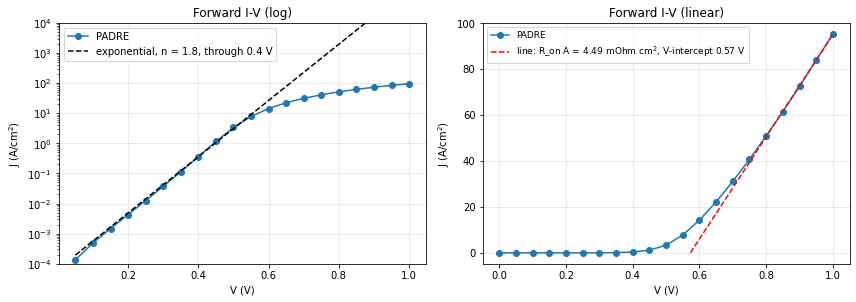

differential on-resistance above 0.8 V : 4.49 mOhm cm^2
ohmic series resistance of the neutral regions (Masetti mobilities): 4.77 mOhm cm^2


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.semilogy(V[1:], J[1:], "o-", label="PADRE")
k04 = np.argmin(abs(V - 0.4))
n_fit = 1.8                                   # measured low-bias ideality (notebook 02 / pntoy review)
ax1.semilogy(V[1:], J[k04] * np.exp((V[1:] - V[k04]) / (n_fit * KT)), "k--",
             label=f"exponential, n = {n_fit}, through 0.4 V")
ax1.set(xlabel="V (V)", ylabel="J (A/cm$^2$)", title="Forward I-V (log)", ylim=(1e-4, 1e4))
ax1.legend()
ax2.plot(V, J, "o-", label="PADRE")
hi = V >= 0.8
slope, icpt = np.polyfit(J[hi], V[hi], 1)                 # V = Vx + R_on * J
ax2.plot(np.linspace(icpt, 1.0, 20), (np.linspace(icpt, 1.0, 20) - icpt) / slope, "r--",
         label=f"line: R_on A = {slope * 1e3:.2f} mOhm cm$^2$, V-intercept {icpt:.2f} V")
ax2.set(xlabel="V (V)", ylabel="J (A/cm$^2$)", title="Forward I-V (linear)")
ax2.legend(fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

R_textbook = rho_p * Wp[-1] + rho_n * Wn[-1]
print(f"differential on-resistance above 0.8 V : {slope * 1e3:.2f} mOhm cm^2")
print(f"ohmic series resistance of the neutral regions (Masetti mobilities): {R_textbook * 1e3:.2f} mOhm cm^2")

**What is different, and why**
* On the log plot, the exponential (textbook) extrapolation parts from PADRE above ~0.55 V and predicts a current more
  than a thousand times too large at 1.0 V.
* On the linear plot, the high-bias points fall on a straight line. Its slope, 4.5 mΩ·cm², is within 6% of the ohmic
  resistance of the neutral regions (4.8 mΩ·cm², slightly higher for the p-side reasons of Section 7). Its intercept,
  about 0.57 V, sits a little below $V_{bi}$. This is how practical diode models are built: an ideal exponential junction
  plus a series resistor $R_s$.

---
## 9. The distorted band diagram, annotated

Everything together at 0.8 V: the neutral regions tilt (mostly ohmic drop), the junction keeps a small barrier, and
the quasi-Fermi levels are split by far less than $qV$.

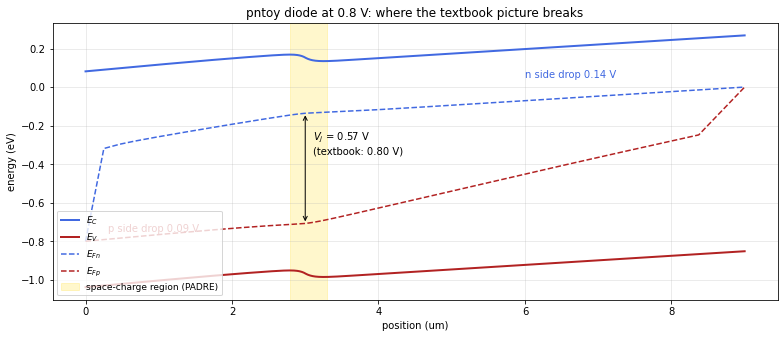

In [12]:
v = 0.8
s = snapshot(sim, v); kl, kr = neutral_edges(s); k = np.argmin(abs(V - v))
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(s["x"], s["ec"], color="royalblue", lw=2, label="$E_C$")
ax.plot(s["x"], s["ev"], color="firebrick", lw=2, label="$E_V$")
ax.plot(s["x"], s["fn"], color="royalblue", ls="--", label="$E_{Fn}$")
ax.plot(s["x"], s["fp"], color="firebrick", ls="--", label="$E_{Fp}$")
ax.axvspan(s["x"][kl], s["x"][kr], color="gold", alpha=0.2, label="space-charge region (PADRE)")
ax.annotate("", xy=(XJ, s["fp"][np.argmin(abs(s['x'] - XJ))]), xytext=(XJ, s["fn"][np.argmin(abs(s['x'] - XJ))]),
            arrowprops=dict(arrowstyle="<->", color="black"))
ax.text(XJ + 0.1, -0.35, f"$V_j$ = {Vj[k]:.2f} V\n(textbook: {v:.2f} V)", fontsize=10)
ax.text(0.3, s["fp"][0] + 0.05, f"p side drop {Vp[k]:.2f} V", color="firebrick")
ax.text(6.0, 0.05, f"n side drop {Vn[k]:.2f} V", color="royalblue")
ax.set(xlabel="position (um)", ylabel="energy (eV)", title=f"pntoy diode at {v} V: where the textbook picture breaks")
ax.legend(fontsize=9, loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10. Fixing it: a preview of notebook 11

Sections 5–8 traced the distortion to one product: the current density $J$ times the series resistance $R_s$ of the
neutral regions. Once $J\,R_s$ is no longer small compared with the applied voltage, the junction stops receiving $V$
and the neutral bands tilt. The fixes follow directly. Each one attacks a different ingredient:

| Fix | Mechanism it attacks | What should happen at 0.8 V |
|---|---|---|
| **1. more doping** (both sides ×100) | $V_{bi}$ and $V_{HI}$ rise by 0.24 V, $R_s$ falls ~55×, less current at the same voltage | 0.8 V is now *below* $V_{bi}$: a textbook drawing exists again |
| **2. better silicon** ($\tau$ = 1 µs instead of 0.1 ns) | less recombination, so less current $J$ at the same voltage | smaller ohmic drop, flatter neutral bands |
| **3. shorter neutral regions** (0.6/1.2 µm instead of 3/6 µm) | the resistors themselves get 5× shorter | smaller ohmic drop, despite more current |

Below, each fix is shown **side by side with the pntoy default at the same 0.8 V**. Wherever the textbook can draw a
band diagram (that is, $V<V_{bi}$ for that design), its $E_C$ and $E_V$ are overlaid as dotted lines.

In [13]:
def band_panel(ax, sim_, v, title):
    # one band diagram at bias v, annotated with the voltage budget and the textbook overlay if one exists
    m, s = sim_.meta, snapshot(sim_, v)
    Vb, Vjb, Vpb, Vnb = voltage_budget(sim_)
    k = np.argmin(abs(Vb - v))
    ax.plot(s["x"], s["ec"], color="royalblue", lw=2, label="$E_C$")
    ax.plot(s["x"], s["ev"], color="firebrick", lw=2, label="$E_V$")
    ax.plot(s["x"], s["fn"], color="royalblue", ls="--", label="$E_{Fn}$")
    ax.plot(s["x"], s["fp"], color="firebrick", ls="--", label="$E_{Fp}$")
    vbi_d = KT * np.log(m["Na"] * m["Nd"] / NI ** 2)
    tb = textbook_bands(s["x"], v, s["ec"][-1], Na=m["Na"], Nd=m["Nd"], xj=m["xj"])
    if tb is not None:
        eg = s["ec"][0] - s["ev"][0]
        ax.plot(s["x"], tb[0], color="black", ls=":", lw=2, label="textbook")
        ax.plot(s["x"], tb[0] - eg, color="black", ls=":", lw=2)
        note = f"V < V$_{{bi}}$ = {vbi_d:.2f} V: textbook curve drawn"
    else:
        note = f"V > V$_{{bi}}$ = {vbi_d:.2f} V: no textbook curve"
    ax.axvline(m["xj"], color="gray", lw=0.5)
    ax.set_title(f"{title}\njunction gets {Vjb[k]:.2f} V ({Vjb[k] / v * 100:.0f}%); "
                 f"p side {Vpb[k]:.2f} V, n side {Vnb[k]:.2f} V", fontsize=10)
    ax.text(0.02, 0.03, note, transform=ax.transAxes, fontsize=9, color="dimgray")
    ax.set(xlabel="position (um)", ylabel="energy (eV)"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")


def side_by_side(fixed, label, v=0.8):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
    band_panel(axes[0], sim, v, f"pntoy default, V = {v} V")
    band_panel(axes[1], fixed, v, f"{label}, V = {v} V")
    plt.tight_layout(); plt.show()


FIXES = {
    "more doping (x100)":        dict(Na=2e17, Nd=1e17),
    "better silicon (tau 1 us)": dict(tau=1e-6),
    "shorter (0.6/1.2 um)":      dict(p_len=0.6, n_len=1.2),
}
fixed_sims = {}
for label, kw in FIXES.items():
    fixed_sims[label] = pntoy_diode(**kw)
    assert fixed_sims[label].run().returncode == 0, label
print("three fixed designs solved, 0 to 1.0 V")

Using cached results from '/tmp/nbrun_padre/pn_junction_diode_6f1fd9b3b4683c246f3eb6cee81bb93d'
Using cached results from '/tmp/nbrun_padre/pn_junction_diode_d6b6c4454c661114f57187043bf22fdb'
Using cached results from '/tmp/nbrun_padre/pn_junction_diode_57740aebd9e021f8dbd4b142e751f79d'
three fixed designs solved, 0 to 1.0 V


### 10.1 Fix 1: more doping. Moves the high-injection limit and the $V_{bi}$ wall

Raising both dopings 100× raises $V_{bi}$ from 0.61 to 0.85 V and $V_{HI}$ of the light side from 0.60 to 0.83 V. At the
same time it cuts the series resistance of the neutral regions about 55× (100× more carriers, but lower mobility), and
the current at a given voltage falls (6× at 0.6 V).

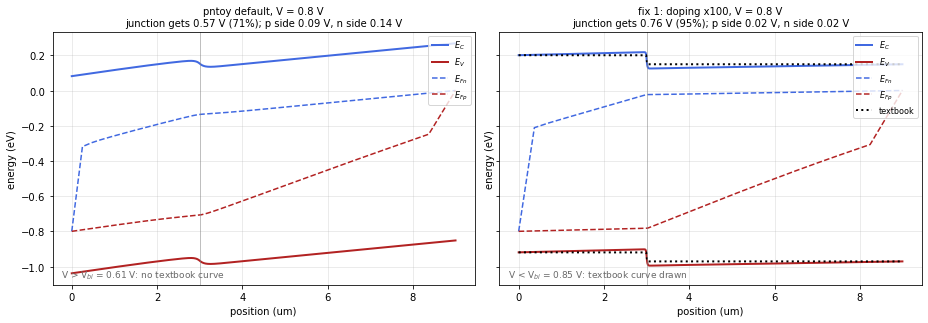

In [14]:
side_by_side(fixed_sims["more doping (x100)"], "fix 1: doping x100")

### 10.2 Fix 2: better silicon. Less current through the same resistors

With $\tau$ = 1 µs the diffusion lengths (≈ 35–60 µm) exceed the neutral regions, recombination nearly disappears, and the
current at a given voltage roughly halves. $V_{bi}$ and $V_{HI}$ do not change, so this fix acts only on the
$J$ in $J\,R_s$.

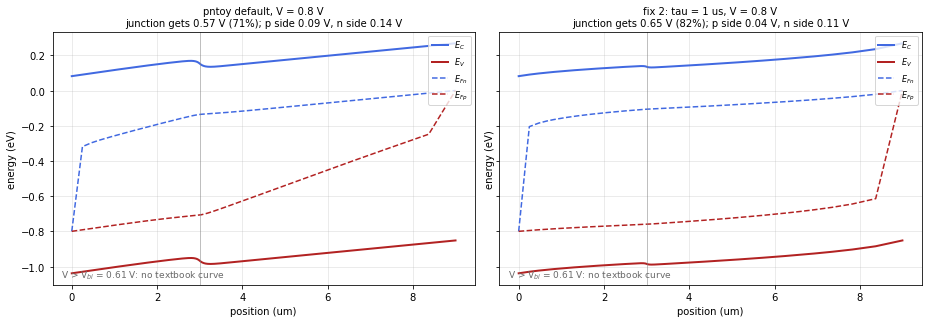

In [15]:
side_by_side(fixed_sims["better silicon (tau 1 us)"], "fix 2: tau = 1 us")

### 10.3 Fix 3: shorter neutral regions. Smaller resistors

Shrinking the p and n regions 5× shortens both resistors 5×. The contacts now sit close to the junction, so the diode
becomes short-base and carries *more* current. The question is which effect wins. Note the different x-axis:
this device is only 1.8 µm long.

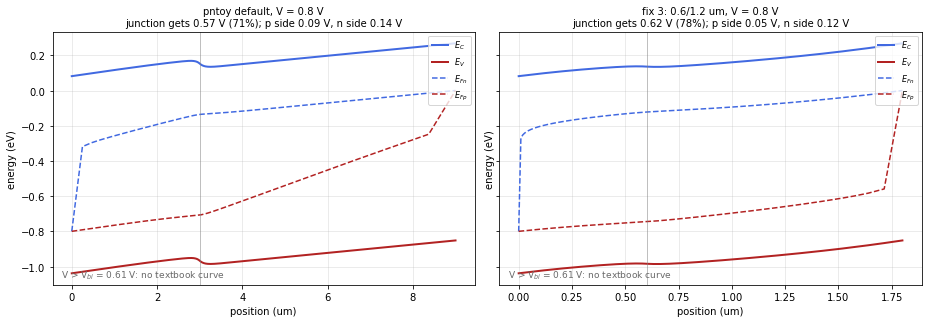

In [16]:
side_by_side(fixed_sims["shorter (0.6/1.2 um)"], "fix 3: 0.6/1.2 um")

### 10.4 The three fixes in one picture

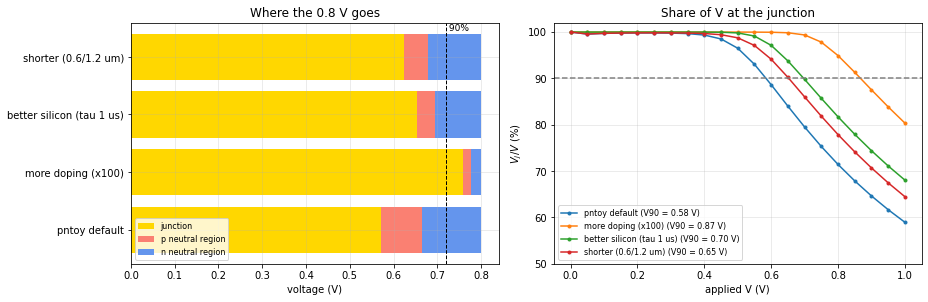

design                        V_j at 0.8 V   share     V90
pntoy default                      0.571 V     71%   0.58 V
more doping (x100)                 0.759 V     95%   0.87 V
better silicon (tau 1 us)          0.654 V     82%   0.70 V
shorter (0.6/1.2 um)               0.623 V     78%   0.65 V


In [17]:
designs = {"pntoy default": sim, **fixed_sims}
v = 0.8
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3))
names, bud, v90s = list(designs), [], []
for nm in names:
    Vb, Vjb, Vpb, Vnb = voltage_budget(designs[nm])
    k = np.argmin(abs(Vb - v))
    bud.append((Vjb[k], Vpb[k], Vnb[k])); v90s.append(fidelity_limit(Vb, Vjb))
    f = np.where(Vb > 0, Vjb / np.maximum(Vb, 1e-12), 1) * 100
    ax2.plot(Vb, f, "o-", ms=3, label=f"{nm} (V90 = {v90s[-1]:.2f} V)")
bud = np.array(bud)
ax1.barh(names, bud[:, 0], color="gold", label="junction")
ax1.barh(names, bud[:, 1], left=bud[:, 0], color="salmon", label="p neutral region")
ax1.barh(names, bud[:, 2], left=bud[:, 0] + bud[:, 1], color="cornflowerblue", label="n neutral region")
ax1.axvline(0.9 * v, color="black", ls="--", lw=1); ax1.text(0.9 * v, 3.45, " 90%", fontsize=9)
ax1.set(xlabel="voltage (V)", title=f"Where the {v} V goes"); ax1.legend(fontsize=8, loc="lower left")
ax2.axhline(90, color="gray", ls="--")
ax2.set(xlabel="applied V (V)", ylabel="$V_j/V$ (%)", title="Share of V at the junction", ylim=(50, 102))
ax2.legend(fontsize=8)
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'design':<28}{'V_j at 0.8 V':>14}{'share':>8}{'V90':>8}")
for nm, (a, b, c), v90 in zip(names, bud, v90s):
    print(f"{nm:<28}{a:>12.3f} V{a / v * 100:>7.0f}%{v90:>7.2f} V")

**What the pictures show.** At 0.8 V the pntoy default's junction receives 71% of the bias. All three fixes help:
* **More doping** is the only one that restores a true textbook drawing. The junction receives 95%, the neutral bands
  are flat, and PADRE's bands lie on the dotted depletion-approximation curve, because 0.8 V is now below $V_{bi}$ = 0.85 V.
* **Better silicon** (82%) and **shorter neutral regions** (78%) flatten the neutral bands, but 0.8 V is still above
  $V_{bi}$ = 0.61 V, so the junction cannot take the whole bias. In the short device the smaller resistors win, even
  though it carries about 7× more current.

**Going deeper: [notebook 11](11_Keeping_the_Textbook_Picture.ipynb)** turns this preview into a systematic study. It
defines the *textbook limit* $V_{90}$ (the highest bias at which the junction still receives 90% of $V$) and measures it
for thirteen designs:
* doping on both sides (×10, ×100) and on one side only, to show why the **lightly doped side** sets the limit;
* four device lengths, which show that "a bigger device" is actually slightly *worse*;
* the diode's area, which changes nothing at all;
* three lifetimes, where the gain saturates once the diffusion length exceeds the device;
* 250 K and 400 K, where a hot diode loses the textbook picture already at 0.21 V.

It ends with a rule of thumb for any p-n junction: the textbook band diagram holds while $J\cdot R_s$ stays below
about 10% of the applied voltage.

---
## 11. Summary: textbook vs. simulation for the pntoy diode

| Statement | Textbook | PADRE, pntoy defaults | Holds up to |
|---|---|---|---|
| all of V across the junction | $V_j=V$ | 99% at 0.4 V, 89% at 0.6 V, 59% at 1.0 V | 0.58 V (90% criterion) |
| flat QFLs split by $qV$ | $E_{Fn}-E_{Fp}=qV$ | flat, but split by $qV_j<qV$ | same as above |
| flat bands in neutral regions | no field | tilt grows above ~0.5 V | ≈ 0.5 V |
| law of the junction | $p_n=\frac{n_i^2}{N_D}e^{qV/kT}$ | right with $V_j$, 27× too high with $V$ at 0.6 V | ≈ 0.5 V |
| low injection | $p_n\ll N_D$ | $p_n/N_D$ ≈ 0.04 at 0.6 V, ≈ 0.4 at 1.0 V | approached, not reached |
| barrier $q(V_{bi}-V)$ | undefined above $V_{bi}$ | small barrier remains; $V_j$ stalls at 0.59 V | $V_{bi}$ = 0.61 V |
| exponential I-V | $J\propto e^{qV/nkT}$ | linear (resistor) above ~0.8 V | ≈ 0.5 V |

The textbook picture is excellent at low bias. It fails when the exponentially growing current makes the ohmic drop in
the neutral regions comparable to $kT/q$, which for pntoy's defaults happens just below $V_{bi}$ and $V_{HI}$. From then on
the junction voltage stalls and the extra bias tilts the neutral regions.

---
## 12. Exercises
1. **Reproduce it in pntoy.** Run the [pntoy tool](https://nanohub.org/tools/pntoy) with its defaults and look at the
   last bias point's energy band diagram (0.6 V). Can you see the start of the tilt in the n region?
2. **Where is the lightly doped side?** Swap the doping ($N_A$ = 10¹⁵, $N_D$ = 2×10¹⁵) with `pntoy_diode(Na=1e15, Nd=2e15)`.
   Which neutral region now takes the larger voltage drop, and why? (Remember the electron and hole mobilities differ.)
3. **Diffusion length.** Plot $E_{Fn}$ on the p side at 0.4 V and measure the distance over which it merges with $E_{Fp}$.
   Compare with $L_n=\sqrt{D_n\tau_n}$ using the Masetti mobility at 2×10¹⁵ cm⁻³.
4. **Reverse bias.** Modify `pntoy_diode` to sweep to −5 V. Does the textbook depletion width hold? (It should, much better:
   reverse bias has no injection and almost no current.)

**Next →** [11 — Keeping the Textbook Picture](11_Keeping_the_Textbook_Picture.ipynb)